# Assignment 3
### - *Aidan Robin*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('life_expectancy.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_').str.replace('/', '_')
df = df.drop(columns=['unnamed:_0'])
print(df.shape)
df.head()

(1649, 20)


,countrystatus,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Outlier Detection

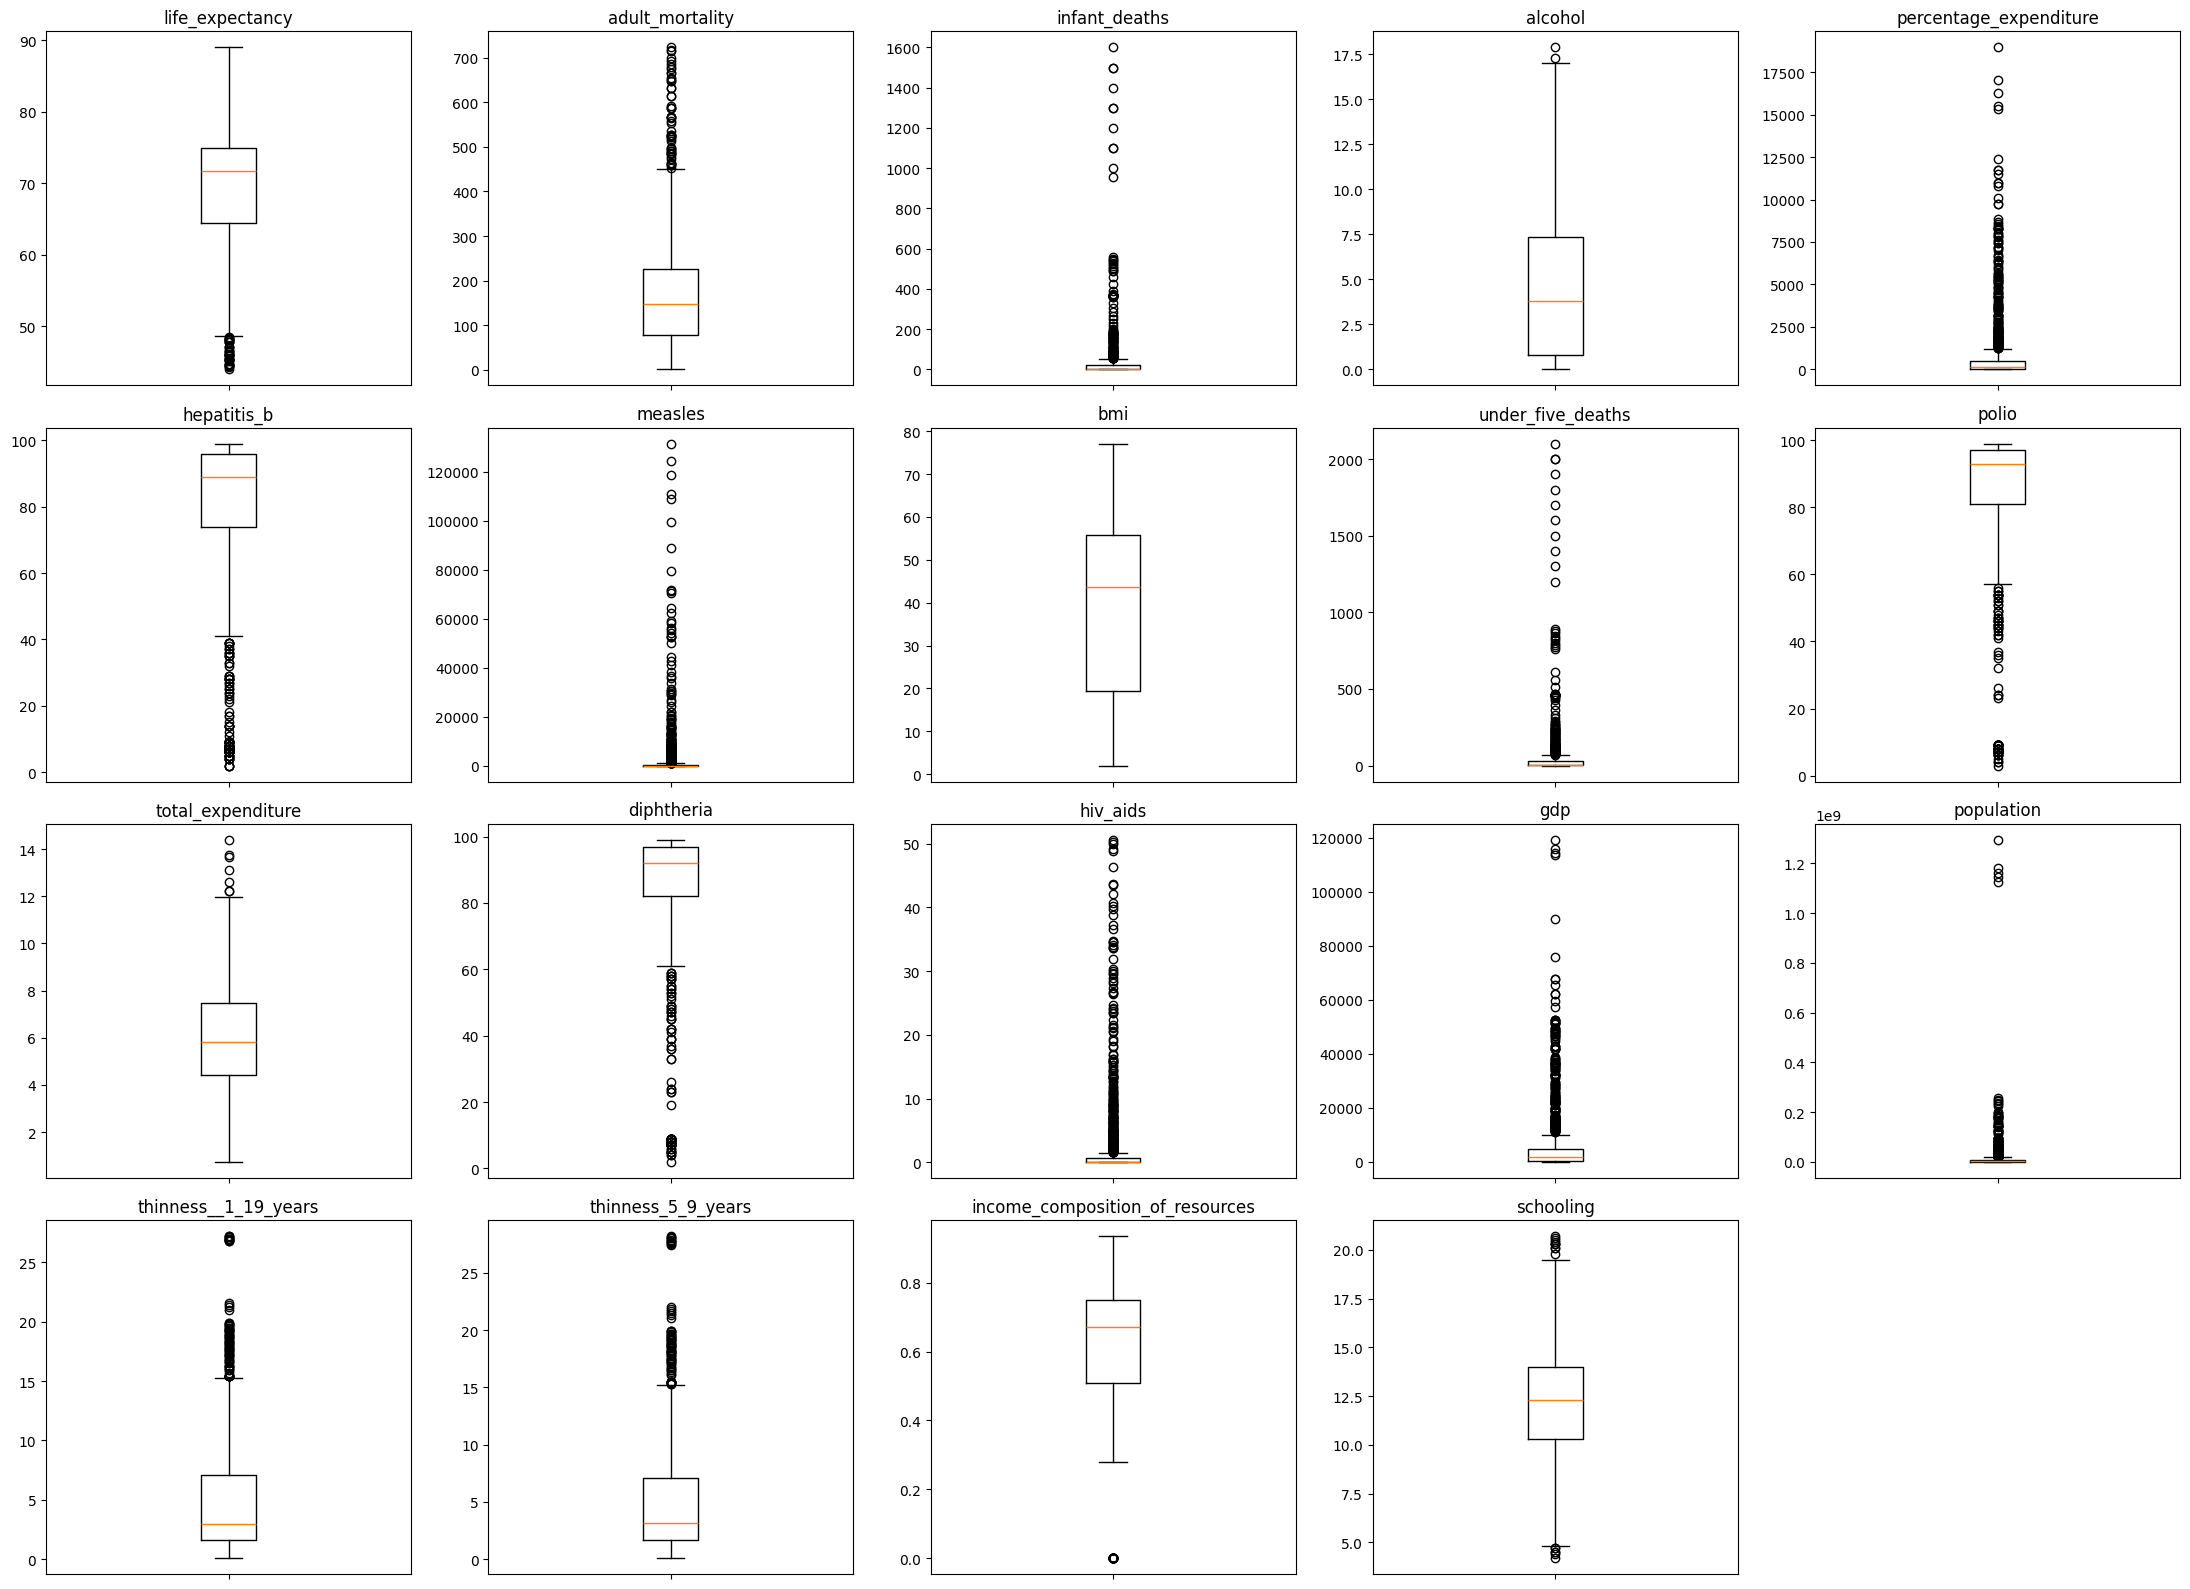

In [2]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### Outlier Decision & Justification

The box plots reveal that many features contain values flagged as statistical outliers by the IQR rule (1.5× IQR). However, we choose to keep all outliers for the following reasons:

1. Many outlier values represent real-world extremes. For example, countries with very high HIV/AIDS mortality, extremely large populations or near-zero GDP per capita are genuine data points
2. Several features (measles, infant_deaths, under_five_deaths, population) are naturally right-skewed with extreme upper tails. These values are valid and informative for the model.
3. The dataset has only 1,649 rows. Dropping hundreds of rows would remove lots of data
4. Rather than dropping outliers, we will apply transformations to heavily skewed features. This compresses extreme values without discarding any data.


## Centering & Scaling
### Histograms of Continuous Features


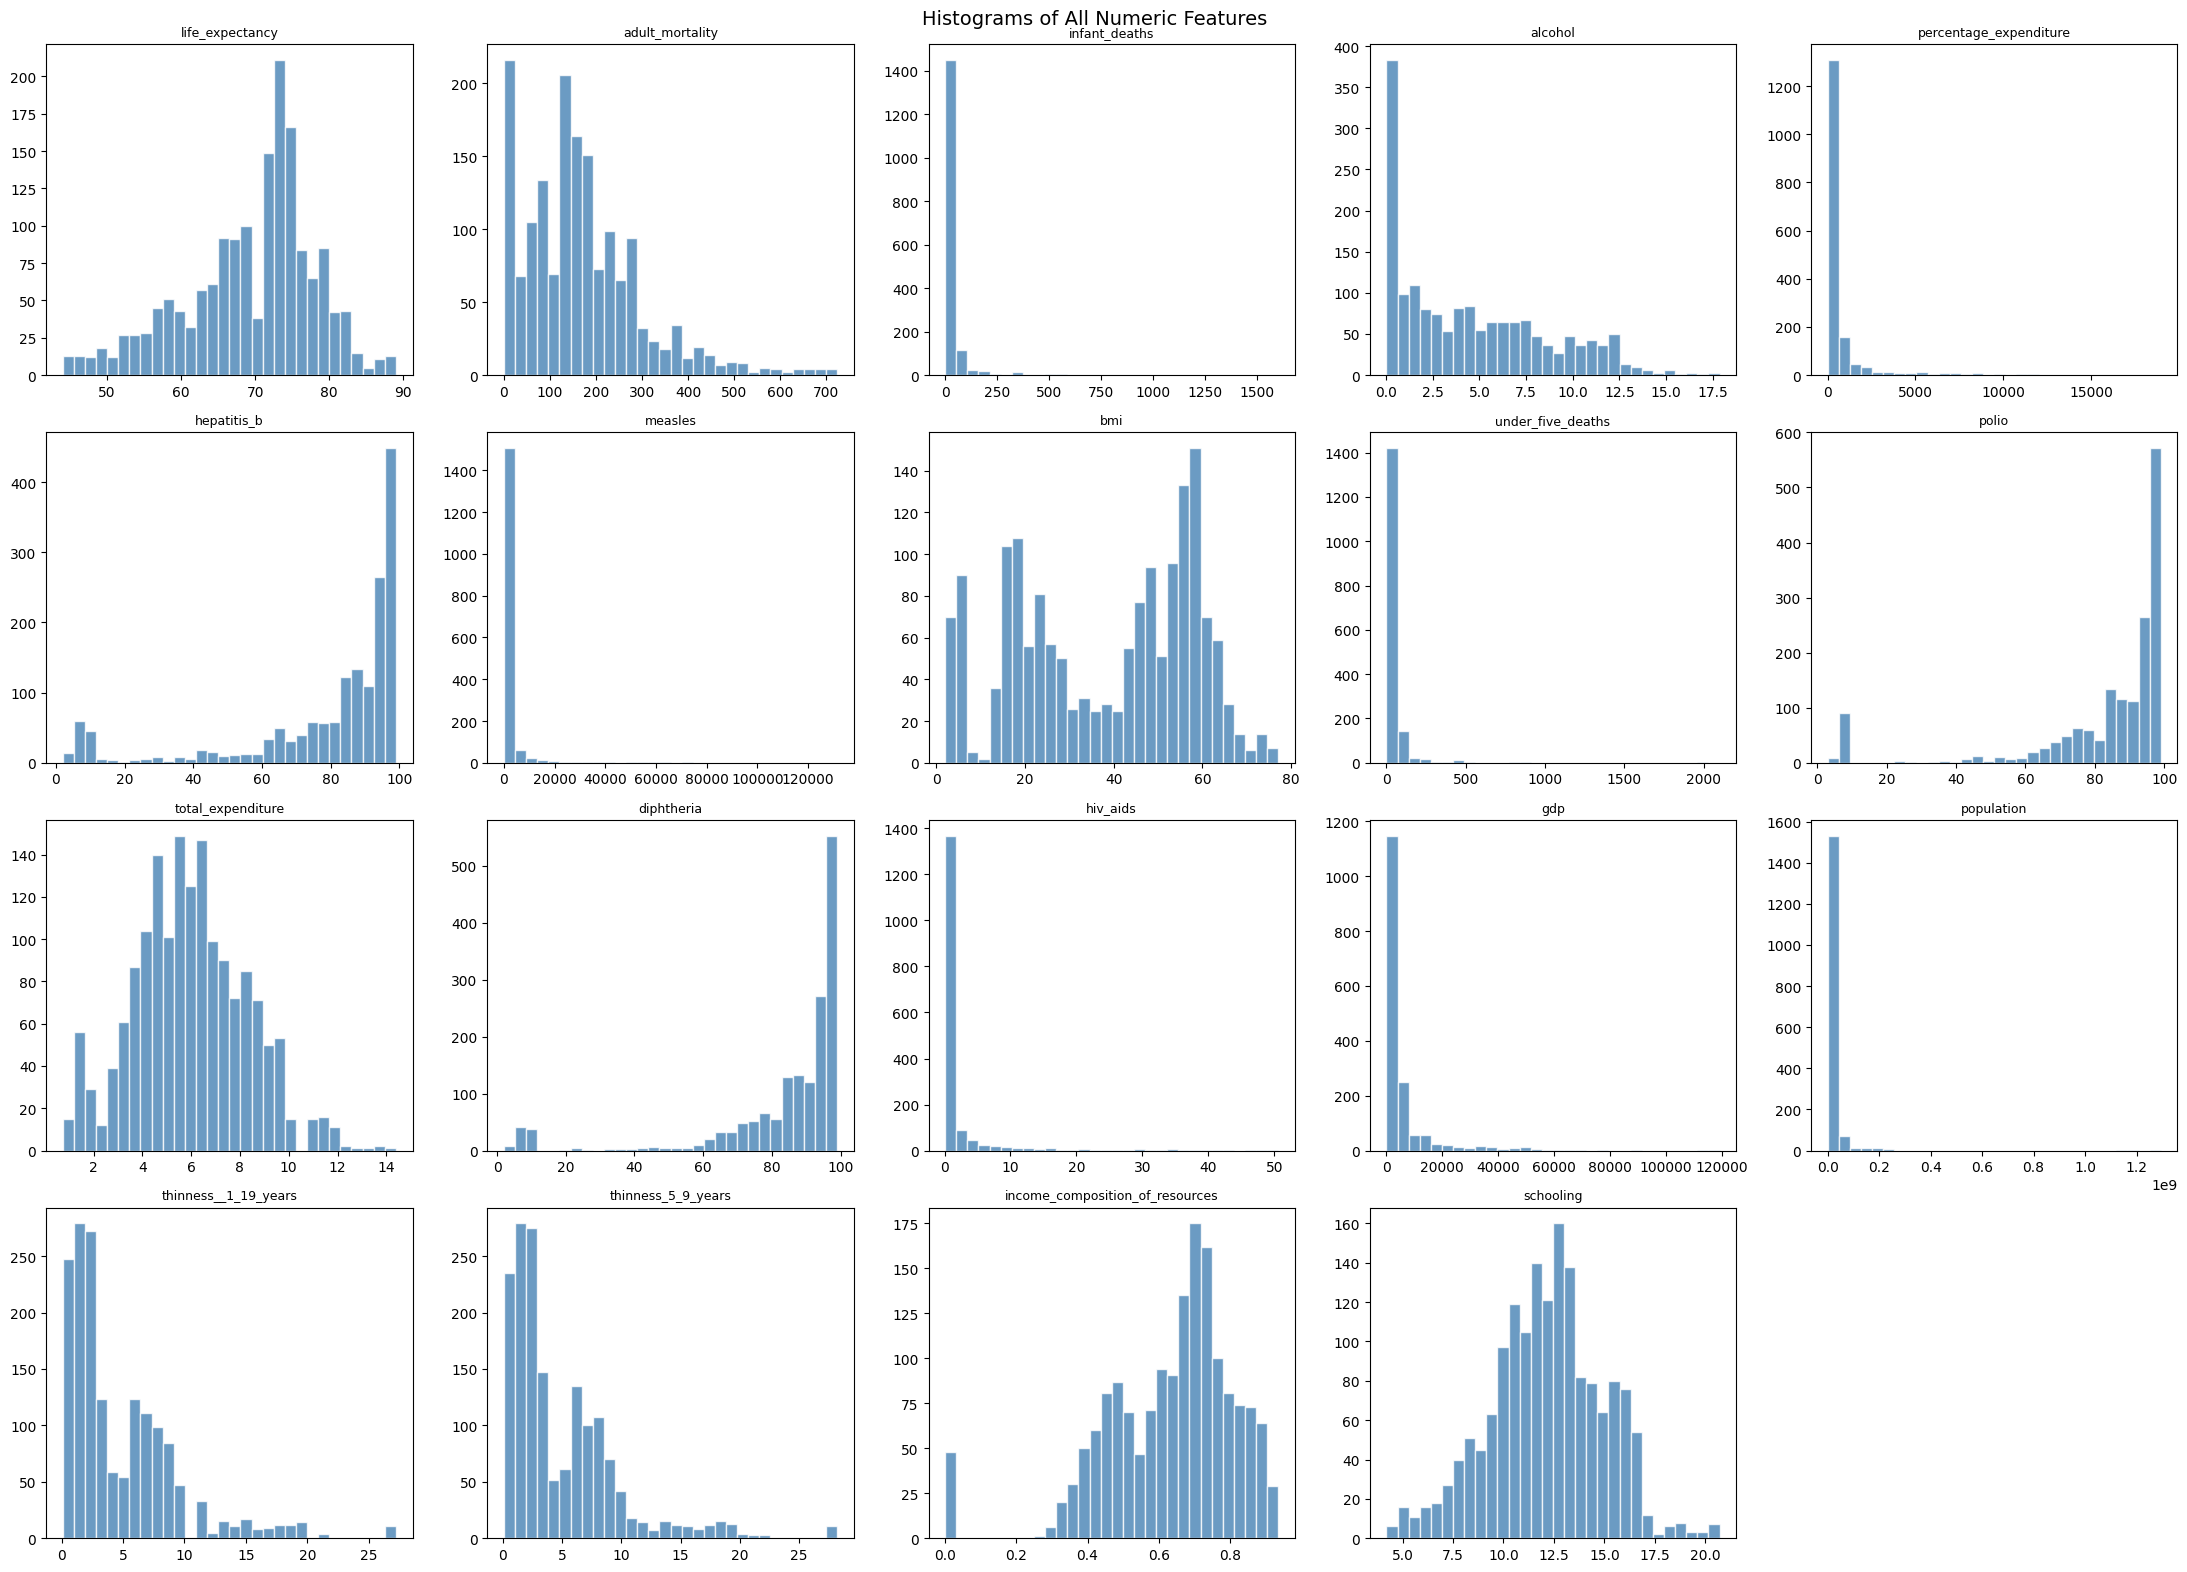

In [3]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Histograms of All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

### Scaling Justification

The histograms show that the features have vastly different scales and units. It is necessary to scale and center the data to make it easier to work with.

I've decide to use standard scaling to center/scale the data, which will be done using StandardScaler from skleran. This is appropriate because it condenses data points on large scales to a z-score.

## Data Transformation


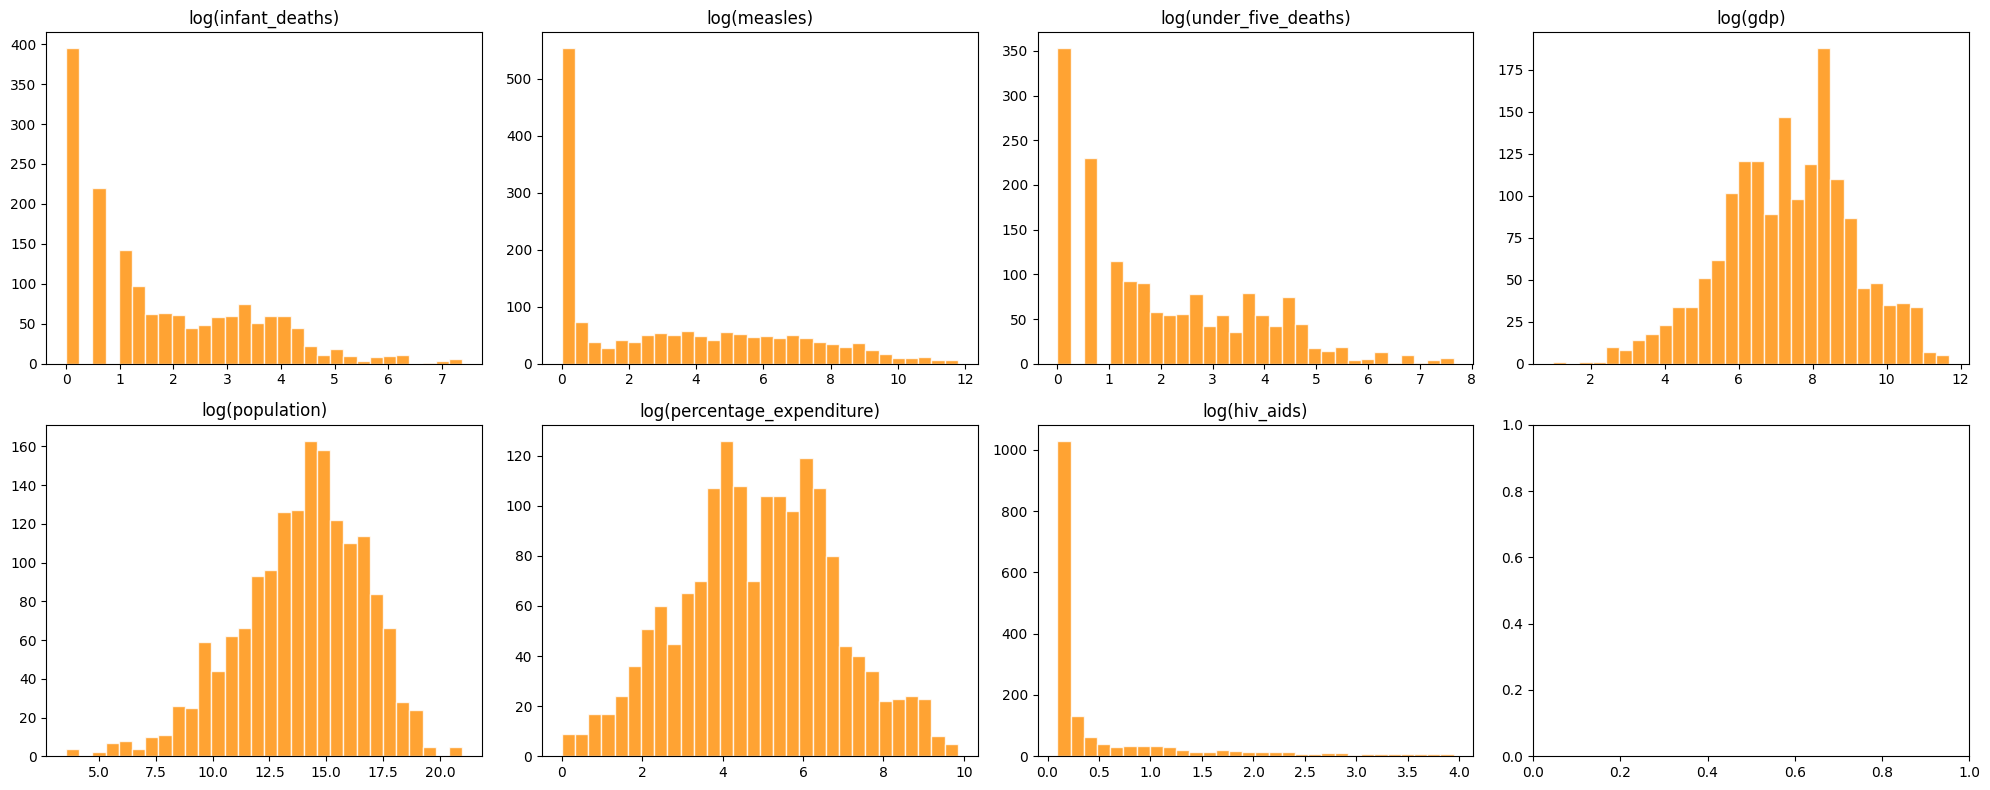

In [4]:
right_skewed = ['infant_deaths','measles','under_five_deaths','gdp',
                'population','percentage_expenditure','hiv_aids']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(right_skewed):
    axes[i].hist(np.log1p(df[col]), bins=30, color='darkorange', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'log({col})', fontsize=12)
plt.tight_layout()
plt.show()

for col in right_skewed:
    df[f'log_{col}'] = np.log1p(df[col])

### Transformation Justification

Seven features exhibited severe right-skewness.These features had very long right tails driven by a small number of countries with extreme values.

To tranform these values, I used log tranformation. After dointg the tranformation, the distributions become more symmetric and bell-shaped. 

The other features were already roughly symmetric and did not require transformation. 

The variable **life_expectancy** was not transformed, as that is thre response variable.


## Statistical Assumptions of Linear Regression

Linear regression relies on the assumptions of **normality, linearity, and independence**.

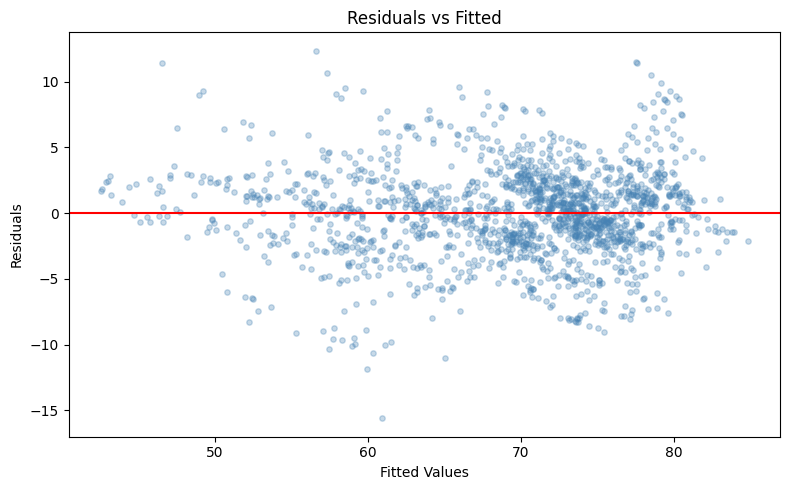

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
check_feats = ['adult_mortality','log_hiv_aids','income_composition_of_resources',
               'schooling','bmi','log_gdp','diphtheria']
X_chk = df[check_feats].fillna(df[check_feats].median())
y_chk = df['life_expectancy']
sc = StandardScaler()
X_chk_s = sc.fit_transform(X_chk)
m_chk = LinearRegression().fit(X_chk_s, y_chk)
resid = y_chk - m_chk.predict(X_chk_s)

ax.scatter(m_chk.predict(X_chk_s), resid, alpha=0.3, color='steelblue', s=15)
ax.axhline(0, color='red', lw=1.5)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
plt.tight_layout()
plt.show()

### Assumption Check Results

- **Normality** : The life_expectancy historgram is roughly normally distributed.
- **Linearity** : Mostly satisfied after log-transforming skewed predictors. A slight curve in the residual at the extremes, but is overall linear. However, even after log transformation, *under_five, infant_deaths, and hiv_aids* are still skewed.
- **Independence** : This cannot really be assumed. The observations per country are likely to be related.



## Dummy Variable Encoding


In [6]:
df['status_dummy'] = (df['countrystatus'] == 'Developed').astype(int)
print(df['countrystatus'].value_counts())
print('\nDummy encoding: Developed=1, Developing=0')
df.head()

countrystatus
Developing    1407
Developed      242
Name: count, dtype: int64

Dummy encoding: Developed=1, Developing=0


,countrystatus,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,...,income_composition_of_resources,schooling,log_infant_deaths,log_measles,log_under_five_deaths,log_gdp,log_population,log_percentage_expenditure,log_hiv_aids,status_dummy
0,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,...,0.479,10.1,4.143135,7.051856,4.430817,6.372055,17.334091,4.280542,0.09531,0
1,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,...,0.476,10.0,4.174387,6.200509,4.465908,6.419501,12.699497,4.311116,0.09531,0
2,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,...,0.470,9.9,4.204693,6.066108,4.499810,6.450067,17.272826,4.307023,0.09531,0
3,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,...,0.463,9.8,4.248495,7.933080,4.543295,6.508708,15.123021,4.371777,0.09531,0
4,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,...,0.454,9.5,4.276666,8.011023,4.584967,4.167242,14.906964,2.091507,0.09531,0


The countrystatus column is a nominal variable that can either be 'Developing' or 'Developed. It was converted to a single dummy variable: **1 = Developed, 0 = Developing**.

## Correlation Heatmap
I maede a correlation heatmap because it would identify which predictors would be best for the model.

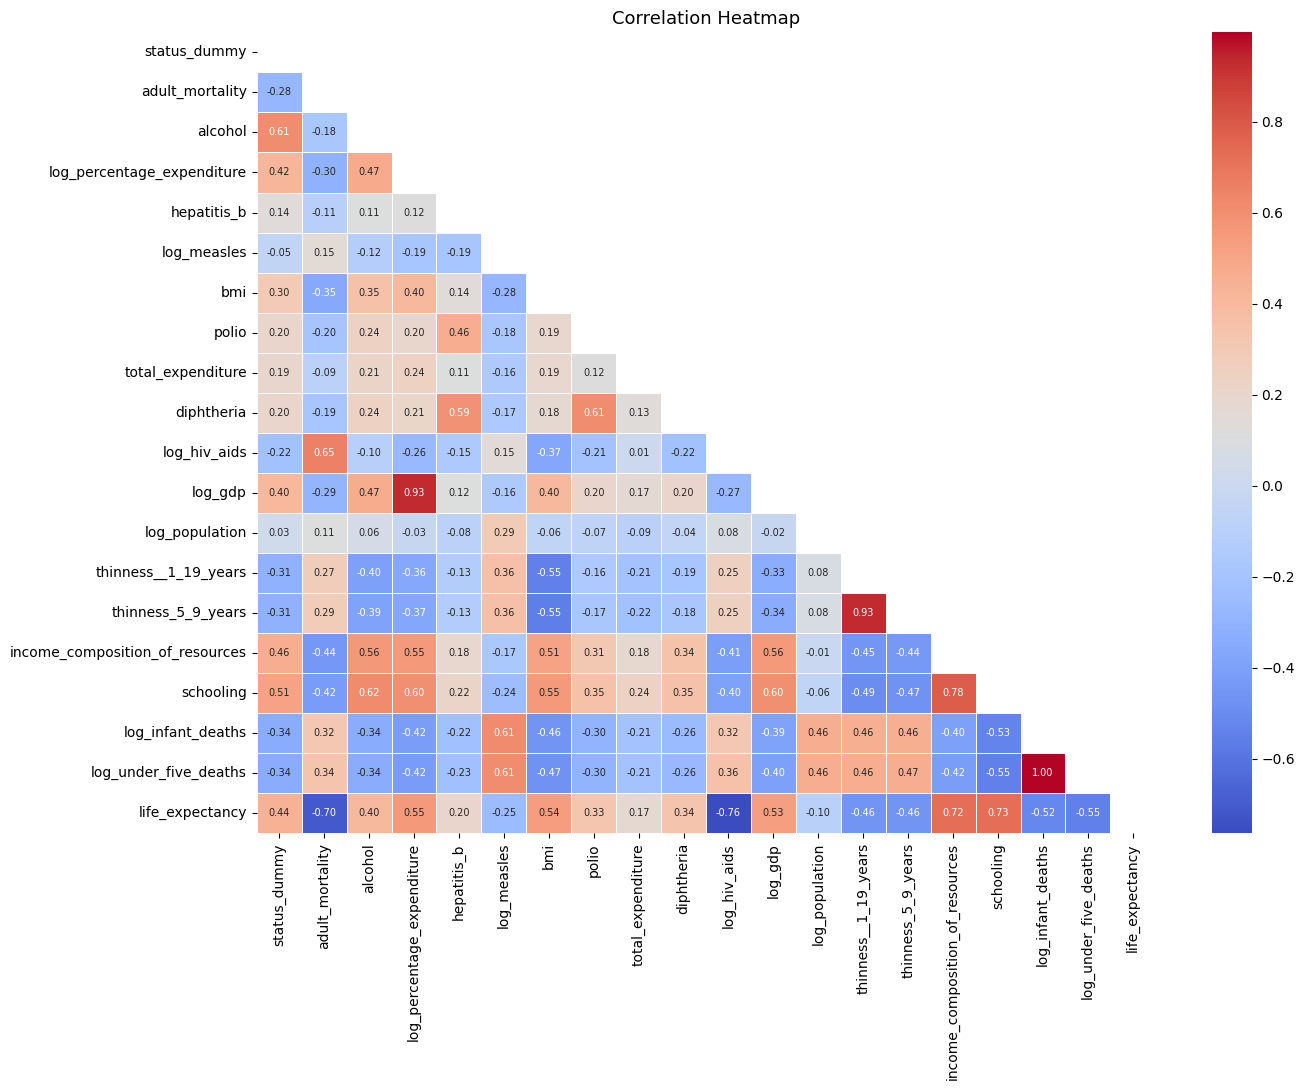

In [7]:
model1_features = ['status_dummy','adult_mortality','alcohol','log_percentage_expenditure',
                   'hepatitis_b','log_measles','bmi','polio','total_expenditure','diphtheria',
                   'log_hiv_aids','log_gdp','log_population','thinness__1_19_years',
                   'thinness_5_9_years','income_composition_of_resources','schooling',
                   'log_infant_deaths','log_under_five_deaths']

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[model1_features + ['life_expectancy']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap', fontsize=13)
plt.tight_layout(); plt.show()

## Linear Regression Models


In [8]:
target = 'life_expectancy'

model1_features = ['status_dummy','adult_mortality','alcohol','log_percentage_expenditure',
                   'hepatitis_b','log_measles','bmi','polio','total_expenditure','diphtheria',
                   'log_hiv_aids','log_gdp','log_population','thinness__1_19_years',
                   'thinness_5_9_years','income_composition_of_resources','schooling',
                   'log_infant_deaths','log_under_five_deaths']

model2_features = ['adult_mortality','log_hiv_aids','income_composition_of_resources',
                   'schooling','bmi','status_dummy','log_gdp','diphtheria']

model3_features = ['adult_mortality','income_composition_of_resources','schooling','log_hiv_aids']

results = {}
for name, feats in [('Model 1 (All)',    model1_features),
                    ('Model 2 (Reduced)', model2_features),
                    ('Model 3 (Minimal)', model3_features)]:
    X = df[feats]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'r2': r2, 'rmse': rmse}
    print(f'{name:25s} | R² = {r2:.4f} | RMSE = {rmse:.4f}')

Model 1 (All)             | R² = 0.8443 | RMSE = 3.3259
Model 2 (Reduced)         | R² = 0.8432 | RMSE = 3.3376
Model 3 (Minimal)         | R² = 0.8273 | RMSE = 3.5025


## Model Evaluation & Interpretation

### R^2 Score

| Model | R^2 | Interpretation |
|---|---|---|
| Model 1 (All, 19 predictors) | 0.8443 | 84.4% of the variance in life expectancy is explained |
| Model 2 (Reduced, 8 predictors) | 0.8432 | 84.3% explained, basically the same as Model 1 |
| Model 3 (Minimal, 4 predictors) | 0.8273 | 82.7% explained, small drop |

The R^2 score is a bit misleading. It will always go up whenever you add a predictor and never decreases. So, model 1 seems to have a better fit than the other models, even thought its likely due to model 1 having significantly more predictors than the other models.

### RMSE Score

| Model | RMSE (years) | Interpretation |
|---|---|---|
| Model 1 | 3.33 | Predictions off by ~3.3 years on average |
| Model 2 | 3.34 | Nearly identical error to Model 1 |
| Model 3 | 3.50 | Slightly higher error with only 4 predictors |

This is a much better evauluation of the models. It also gives an estimation of how far of the residuals are.


## Best Model Assessment

**Best model: Model 1 (All, 19 predictors) - R^2 = 0.8443, RMSE = 3.33 years**

The best model is good by several measures:

- R^2 of 0.84 means the model explains 84% of the variation in life expectancy across countries and years, which is a very strong result.
- RMSE of 3.33 years is clinically and practically meaningful. Predicting life expectancy within ±3–4 years on a global, cross-country dataset is a reasonable level of accuracy. There are many other factors not accounted for in the dataset, yet is still relatively close.

Model 2 (8 predictors) achieves essentially the same R^2 and RMSE as Model 1, suggesting that **Model 2 may be preferable in practice** due to its simplicity, interpretability, and lower risk of overfitting. Even though Model 1 scores higher, it is a marginal difference that is not worth the compute power.

Overall, the model is a solid, interpretable baseline for estimating life expectancy from socioeconomic and health indicators.
